In [1]:
# import necessary packages

# CIL imports
from cil.framework import ImageGeometry, AcquisitionGeometry, BlockDataContainer, ImageData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

from cil.optimisation.functions import LeastSquares, BlockFunction, L2NormSquared

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS, GD

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.operators import BlockOperator, DiagonalOperator, GradientOperator, \
                                        CompositionOperator, ZeroOperator

In [2]:
# setting pixels and angles
n_pixels = 265
n_angles = 50

## setting up

In [3]:
# Set logging level for CIL processors:
logging.basicConfig(level=logging.WARNING)
cil_log_level = logging.getLogger('cil.processors')
cil_log_level.setLevel(logging.INFO)

# Setting background defaults
cmap = "rainbow"
device = "cpu"

In [4]:
# Angles
angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

# Setup acquisition geometry
ag = AcquisitionGeometry.create_Parallel2D()\
                            .set_angles(angles)\
                            .set_panel(n_pixels, pixel_size=1/n_pixels)

# Setup image geometry
ig = ImageGeometry(voxel_num_x=n_pixels, 
                   voxel_num_y=n_pixels, 
                   voxel_size_x=1/n_pixels, 
                   voxel_size_y=1/n_pixels)

# Get phantom
phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

# Create projection operator using Astra-Toolbox.
A = ProjectionOperator(ig, ag, device)

# Create an acquisition data (numerically)
sino = A.direct(phantom)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


## Normal equations

In [5]:
def apply_operator(weights_k, alpha, x):
    
    """
    Applies the operator 
    
    A^TA + alpha *D^T*W_b*D
    
    to the input ImageData x. Used to solve the normal equations 

    (A^TA + alpha * D^T*W_b*D)u = A^Ty

    with W_b = [[W 0],
                [0, W]]
                      
    and W = diag{weights_k}

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights for in W
        alpha:  regularisation parameter

    Output:
        z: ImageData (A^TA + alpha * D^T*W_b*D)x
    """

    get_ig = A.domain_geometry()
    grad_operator = GradientOperator(get_ig)
    diagonal_weights = DiagonalOperator(weights_k)

    # z1 = Dx
    z1 = grad_operator.direct(x)

    # z2 = Wtilde z1
    z2_a = diagonal_weights.direct(z1[0])
    z2_b = diagonal_weights.direct(z1[1])
    z2 = BlockDataContainer(z2_a, z2_b)

    #z3 = D^T z2 = D^T*Wtilde*Dx
    z3 = grad_operator.adjoint(z2)

    # y2 = A^TAx
    y1 = A.direct(x)
    y2 = A.adjoint(y1)

    final = y2 + alpha * z3

    return final

In [6]:
def CG_tv(initial, iteration, b, alpha, Wk):

    """
    Solves for u in the system 

    (A^TA + alpha * D^TW_bD)u = A^Tb

    using CG

    """

    u0 = initial.copy()
    r0 = b - apply_operator(weights_k=Wk, alpha=alpha, x=u0)
    p0 = r0

    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0
    delta_new = rk.dot(rk.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    tol = 1e-2

    # perform CG iterations
    for k in range(iteration):

        # zk = Apk
        zk = apply_operator(weights_k=Wk, alpha=alpha, x=pk)

        alpha_k = delta_new/(pk.dot(zk.conjugate()))
        
        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        delta_new = rk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new/delta_old

        pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)  # should technically be 'b - Ax'
        if check < tol * r0_norm:
            uk = uk_plus_one
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk

In [7]:
def tv_solver_normalcg(initial, inner, outer, A, b, alpha, er):
    """
    Finds a solution for the problem 

    ||Au - b||_2^2 + alpha * TV(u)

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (A^TA + alpha * D^TW_bD)u = A^Tb
    
    with W_b = [[W_k 0],
                [0, W_k]]
                      
    In each outer iterations the matrix W_k is updated (reweighted), 
    W_k = diag{((D_x u)**2 + (D_yu)**2)**(-1/2)}


    Input:
        max_outer:  Number of outer iterations (scalar)
        max_inner:  Number of CG interations (scalar)
        initial:    Initial guess for u (ImageData)
        A:          The acting operator (Operator)
        b:          The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)

    Output:
        uk:         Reconstructed image (ImageData)
    which should be 
    
    """

    uk = initial.copy()

    # create lhs, A^Tb
    lhs = A.adjoint(b)

    # gradient operator 
    get_ig = A.domain_geometry()
    gradient_operator = GradientOperator(get_ig)

    for k in range(outer):
        print(f"outer iteration: {k + 1}")

        # reweight the regularisation term
        grad = gradient_operator.direct(uk)
        uk_grad = grad[0]**2 + grad[1]**2
        uk_grad_np = uk_grad.as_array()
        #print("Before reweighting:", uk_grad_np)

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = uk_grad_np[large_values] ** (-1/2)

        # convert back to ImageData
        uk_reweighted = ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing solve the normal equations
        cg_output = CG_tv(uk, inner, lhs, alpha, uk_reweighted)
        
        uk = cg_output

    return uk


In [8]:
x0 = ig.allocate(0)
alpha = 1e-6
oh_no = tv_solver_normalcg(x0, 100, 10, A, sino, alpha, 0.0001)

outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
cg converged in 79 iterations
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10


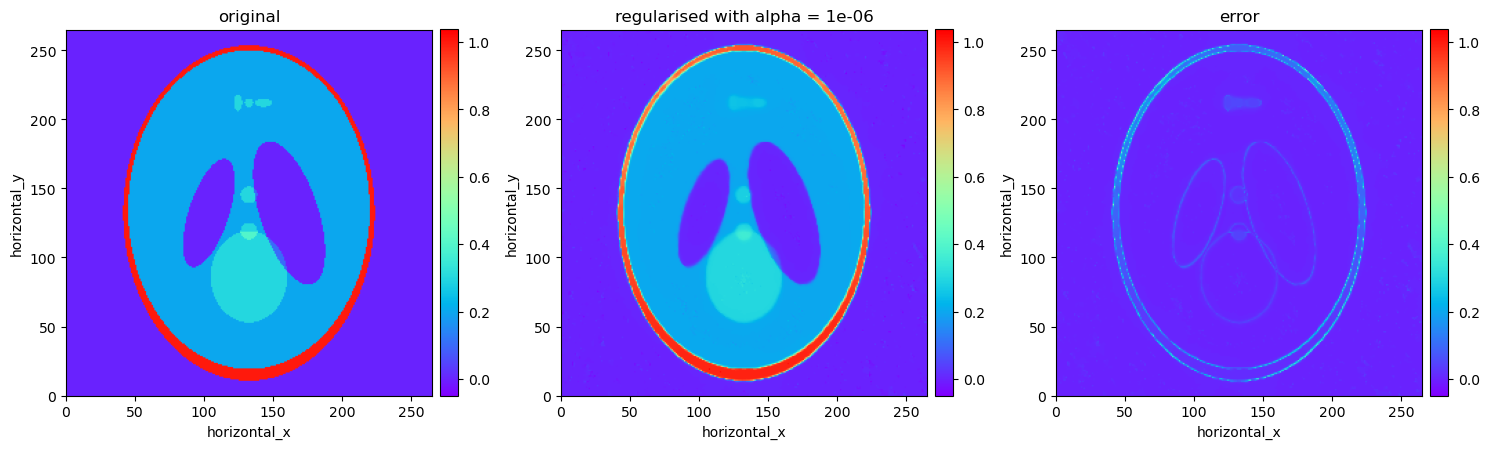

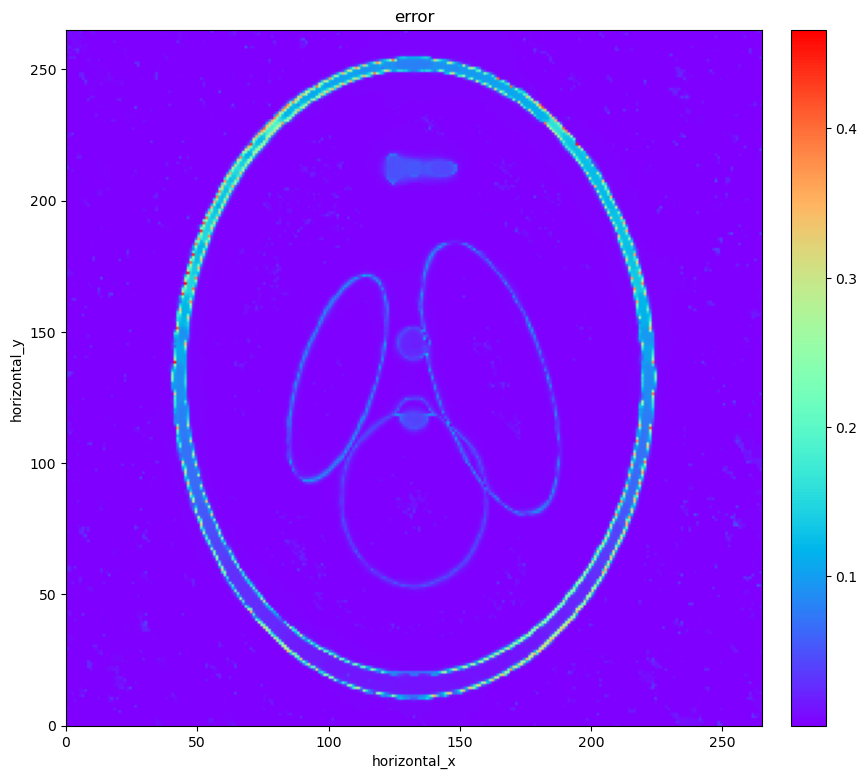

In [9]:
show2D([phantom, oh_no, (oh_no - phantom).abs()], 
       ['original', f'regularised with alpha = {alpha}', 'error'], 
       cmap=cmap, fix_range=True, num_cols =3)

show2D([(phantom - oh_no).abs()], ['error'], cmap=cmap)

In [10]:
def CG_tv(initial, iteration, b, alpha, Wk):

    """
    Solves for u in the system 

    (A^TA + alpha * D^TW_bD)u = A^Tb

    using CG
    """

    u0 = initial.copy()
    r0 = b - apply_operator(weights_k=Wk, alpha=alpha, x=u0)
    p0 = r0

    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    tol = 1e-2

    # perform CG iterations
    for k in range(iteration):
        zk = apply_operator(weights_k=Wk, alpha=alpha, x=pk)

        # NOTE: might need to find something better than adding 1e-6
        alpha_k = (pk.dot(rk.conjugate()))/(pk.dot(zk.conjugate()))
        
        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        temp = apply_operator(weights_k=Wk, alpha=alpha, x=rk_plus_one)
        beta_k = (-pk.dot(temp.conjugate()))/(pk.dot(zk.conjugate()))

        pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)  # should technically be 'b - Ax'
        if check < tol * r0_norm:
            uk = uk_plus_one
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk

## Final code

In [17]:
def get_A(n_angles, n_pixels):

    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # Setup acquisition geometry

    # Note that if number of pixels and number of angels are equal, 
    # the matrix is square and an exact solution can be found, 
    # then there is a sufficient number of pojections
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    A = ProjectionOperator(ig, ag, device='cpu')

    # Get phantom
    phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

    # Create an acquisition data (numerically)
    sino = A.direct(phantom)

    return A, sino, ig, ag, phantom


def add_poss_noise(background_counts, n_angles, n_pixels):
    A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

    # adding noise to the sinogram

    # Convert the simulated absorption sinogram to transmission values using Lambert-Beer. 
    counts_poss = background_counts * np.exp(-sino.as_array())

    # Use as a mean for Poisson data generation.
    noisy_counts_poss = np.random.poisson(counts_poss)
    nonzero = noisy_counts_poss > 0

    # Convert back to absorption sinogram.
    sino_out_poss = np.zeros_like(sino.as_array())
    sino_out_poss[nonzero] = -np.log(noisy_counts_poss[nonzero]/ background_counts)

    # allocate sino_noisy and fill with noisy data
    sino_noisy_poss = ag.allocate()
    sino_noisy_poss.fill(sino_out_poss)

    return sino_noisy_poss

In [34]:
def apply_operator_tv(x, W, A, alpha):
    
    """
    Applies the operator 
    
    A^TA + alpha *D^T*W_b*D
    
    to the input ImageData x. Used to solve the normal equations 

    (A^TA + alpha * D^T*W_b*D)u = A^Ty

    with W_b = [[W 0],
                [0, W]]
                      
    and W = diag{weights_k}

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights for in W
        A:  Projection operator
        alpha:  regularisation parameter

    Output:
        z: ImageData (A^TA + alpha * D^T*W_b*D)x
    """

    get_ig = A.domain_geometry()
    grad_operator = GradientOperator(get_ig)
    diagonal_weights = DiagonalOperator(W)

    # z1 = Dx
    z1 = grad_operator.direct(x)

    # z2 = Wtilde z1
    z2_a = diagonal_weights.direct(z1[0])
    z2_b = diagonal_weights.direct(z1[1])
    z2 = BlockDataContainer(z2_a, z2_b)

    #z3 = D^T z2 = D^T*Wtilde*Dx
    z3 = grad_operator.adjoint(z2)

    # y2 = A^TAx
    y1 = A.direct(x)
    y2 = A.adjoint(y1)

    final = y2 + alpha * z3

    return final

def CG(initial, max_iter, A, ATb, alpha, Wk, cg_tol, apply_operator):

    """
    Solves for u in the system 

    (apply_operator)u = A^Tb

    using CG

    """

    u0 = initial.copy()
    r0 = ATb - apply_operator(x=u0, W=Wk, A=A, alpha=alpha)
    p0 = r0
    
    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0
    delta_new = rk.dot(rk.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    cg_tol *= 2
    rel_tol = r0_norm * cg_tol

    # to check convergence
    conv_arr = []
    conv_arr.append(r0_norm)

    # counting inner iterations
    inner_iter_count = max_iter

    # perform CG iterations
    for k in range(max_iter):

        # zk = Apk
        zk = apply_operator(x=pk, W=Wk, A=A, alpha=alpha)

        alpha_k = delta_new/(pk.dot(zk.conjugate()))
        
        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        delta_new = rk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new/delta_old

        pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(ATb - apply_operator(x=uk, W=Wk, A=A, alpha=alpha))
        #check = norm(rk_plus_one)
        conv_arr.append(check)
        if check < rel_tol:
            uk = uk_plus_one
            inner_iter_count = k + 1
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk, conv_arr, inner_iter_count


def tv_solver_normal(initial, inner_iter, outer_iter, A, sino, alpha, er, cg_tol, exact):
    """
    Finds a solution for the problem 

    ||Au - b||_2^2 + alpha * TV(u)

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (A^TA + alpha * D^TW_bD)u = A^Tb
    
    with W_b = [[W_k 0],
                [0, W_k]]
                      
    In each outer iterations the matrix W_k is updated (reweighted), 
    W_k = diag{((D_x u)**2 + (D_yu)**2)**(-1/2)}


    Input:
        outer_iter:  Number of outer iterations (scalar)
        inner_iter:  Number of CG iterations (scalar)
        initial:    Initial guess for u (ImageData)
        A:          The acting operator (Operator)
        sino:       The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)
        pre:        Determine to put in preconditioner (Boolean)

    Output:
        uk:         Reconstructed image (ImageData)
    which should be 
    
    """
    uk = initial.copy()

    # create lhs, A^Tb
    lhs = A.adjoint(sino)

    # gradient operator 
    get_ig = A.domain_geometry()
    gradient_operator = GradientOperator(get_ig)

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []
    if exact == None:
        err_temp = norm(A.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    inner_itercount_arr = []
    for k in range(outer_iter):
        print(f"outer iteration: {k + 1}")

        # reweight the regularisation term
        grad = gradient_operator.direct(uk)
        uk_grad = grad[0]**2 + grad[1]**2
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = (uk_grad_np[large_values] ** (-1/2))*2
    
        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing solve the normal equations
        cg_output, conv_arr, inner_iter_count = CG(uk, inner_iter, A, lhs, alpha, uk_reweighted, cg_tol, apply_operator_tv)
        inner_itercount_arr.append(inner_iter_count)
    
        uk = cg_output

        if exact == None:
            err_temp = norm(A.direct(uk) - sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er is None:
            e = (A.direct(uk) - sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err, conv_arr, inner_itercount_arr


In [52]:
import time
sino_noise = add_poss_noise(20000, n_angles, n_pixels)
A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

tstart = time.time()
sol100, sol_err100, conv_array100, inner_iterationscounter100 = tv_solver_normal(initial= ig.allocate(0), 
                                                                    inner_iter = 100, 
                                                                    outer_iter = 15, 
                                                                    A = A, 
                                                                    sino = sino_noise, 
                                                                    alpha = 5e-7, 
                                                                    er = None, 
                                                                    cg_tol = 1e-2, 
                                                                    exact = phantom)
tend = time.time()

sol10, sol_err10, conv_array10, inner_iterationscounter10 = tv_solver_normal(initial= ig.allocate(0), 
                                                                    inner_iter = 20, 
                                                                    outer_iter = 15, 
                                                                    A = A, 
                                                                    sino = sino_noise, 
                                                                    alpha = 5e-7, 
                                                                    er = None, 
                                                                    cg_tol = 1e-2, 
                                                                    exact = phantom)

print("time for computation:", tend-tstart)

outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
cg converged in 41 iterations
outer iteration: 3
cg converged in 85 iterations
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10
outer iteration: 11
outer iteration: 12
outer iteration: 13
outer iteration: 14
outer iteration: 15
outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10
outer iteration: 11
outer iteration: 12
outer iteration: 13
outer iteration: 14
outer iteration: 15
time for computation: 195.97915720939636


<>:15: SyntaxWarning: invalid escape sequence '\|'
<>:15: SyntaxWarning: invalid escape sequence '\|'
C:\Users\femke\AppData\Local\Temp\ipykernel_13848\1958977131.py:15: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$\|u_{exact} - u\|_2^2$')


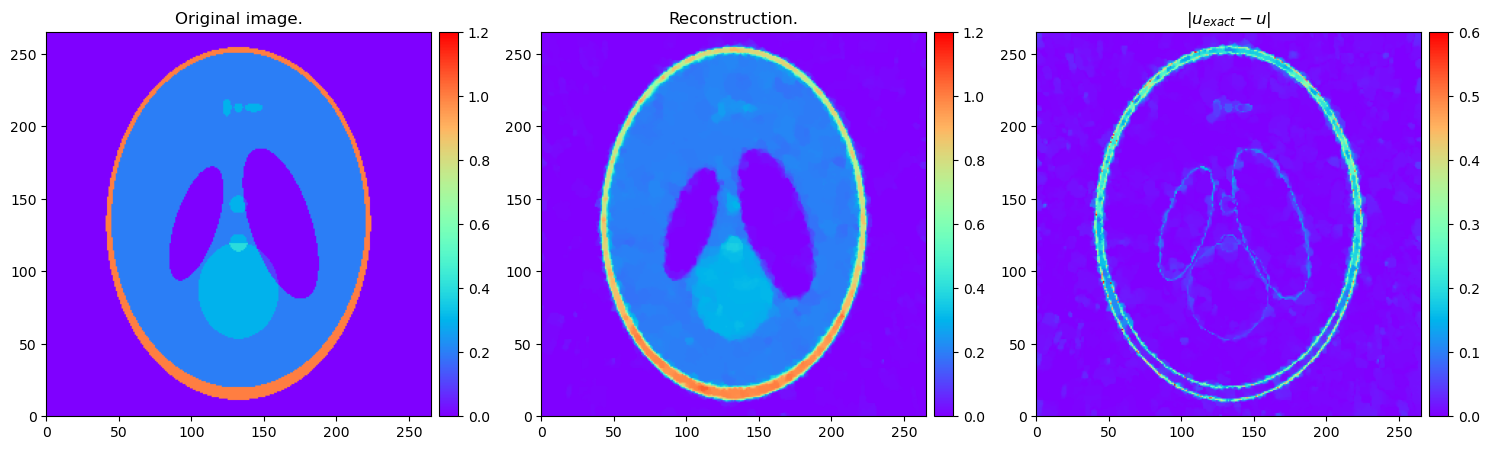

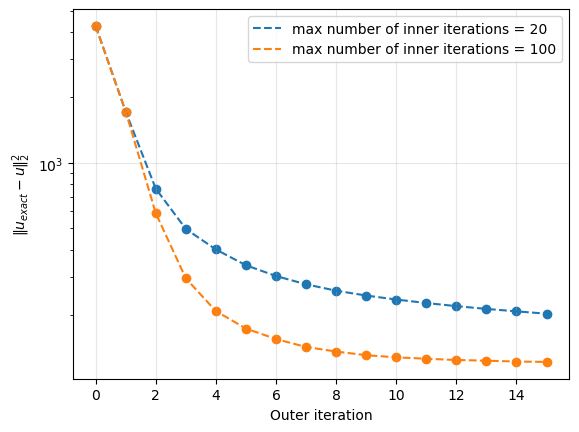

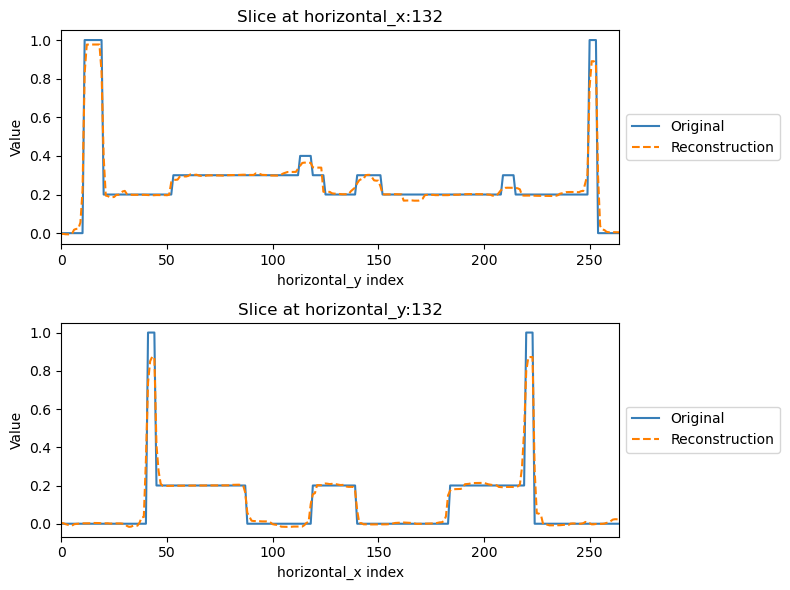

Text(0, 0.5, 'number of inner iterations')

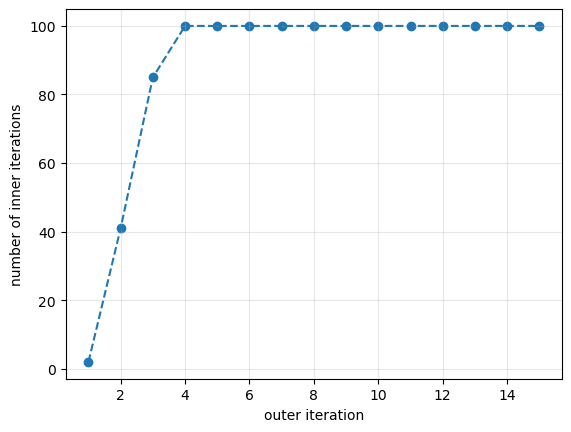

In [64]:
error = (phantom - sol10).abs()
show2D([phantom, sol10, error], ['Original image.', 'Reconstruction.', '$|u_{exact} - u|$'], 
       cmap=cmap, 
       num_cols=3, 
       fix_range=[(0,1.2), (0,1.2), (0,0.6)], 
       axis_labels=('',''))

x = np.linspace(0,len(sol_err10) - 1, len(sol_err10))

#plt.figure(figsize=(12,8))
plt.semilogy(x, sol_err10, linestyle='--', label='max number of inner iterations = 20')
plt.scatter(x,sol_err10)
plt.semilogy(x, sol_err100, linestyle='--', label='max number of inner iterations = 100')
plt.scatter(x, sol_err100)
plt.ylabel('$\|u_{exact} - u\|_2^2$')
plt.xlabel('Outer iteration')
plt.legend()
plt.grid(alpha=0.3)

show1D([phantom, sol10], dataset_labels=['Original', 'Reconstruction'])
x2 = np.linspace(1, len(inner_iterationscounter10), len(inner_iterationscounter10))

#plt.figure(figsize=(12,8))
# plt.scatter(x2, inner_iterationscounter10)
# plt.plot(x2, inner_iterationscounter10, linestyle='--')
plt.scatter(x2, inner_iterationscounter100)
plt.plot(x2, inner_iterationscounter100, linestyle='--')
plt.grid(alpha=0.3)
plt.xlabel('outer iteration')
plt.ylabel('number of inner iterations')

## Some time experiment, that did not really work as I wanted it

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


cg10
outer iteration: 1
cg converged in 2 iterations
cg100
outer iteration: 1
cg converged in 2 iterations
cg10
outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
cg100
outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
cg converged in 40 iterations
cg10
outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
cg100
outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
cg converged in 40 iterations
outer iteration: 3
cg converged in 86 iterations
cg10
outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
outer iteration: 4
cg100
outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
cg converged in 40 iterations
outer iteration: 3
cg converged in 86 iterations
outer iteration: 4
cg10
outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
cg100
outer iteration: 1
cg converged in 2 iterations
outer itera

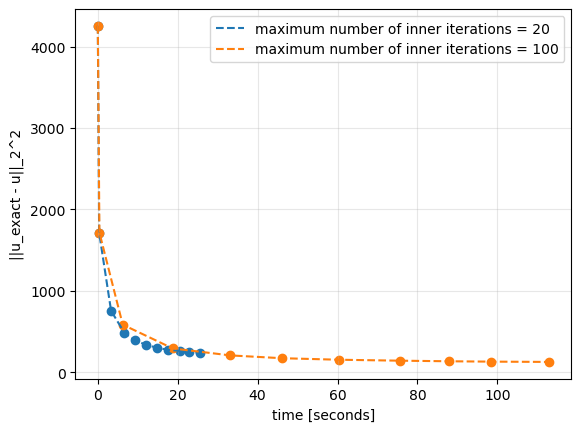

In [ ]:
A, sino, ig, ag, phantom = get_A(50, 265)
sino_noisy = add_poss_noise(20000, 50, 265)
# f1_poss = LeastSquares(A, sino_noisy, (1/2))
norm = L2NormSquared()

iterations = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
time_cg10 = []
time_cg100 = []
#time_fista = []

time_cg10.append(0)
time_cg100.append(0)
#time_fista.append(0)

err_cg100 = []
err_cg10 = []
#err_fista = []

initial_err = norm(phantom)
err_cg100.append(initial_err)
err_cg10.append(initial_err)
#err_fista.append(initial_err)

for it in iterations:

    print("cg10")
    t1_start = time.time()
    sol10, err10, conv_arr10, lala = tv_solver_normal(initial = ig.allocate(0), 
                        inner_iter = 20, 
                        outer_iter = it, 
                        A = A,
                        sino = sino_noisy, 
                        alpha = 5e-7, 
                        er = None, 
                        cg_tol = 1e-2, 
                        exact = phantom)
    t1_end = time.time()

    time_cg10.append(t1_end - t1_start)
    err_cg10.append(norm(phantom - sol10.abs()))

    print("cg100")
    t2_start = time.time()
    sol100, err100, conv_arr100, lala = tv_solver_normal(initial = ig.allocate(0), 
                        inner_iter = 100, 
                        outer_iter = it, 
                        A = A,
                        sino = sino_noisy, 
                        alpha = 5e-7, 
                        er = None, 
                        cg_tol = 1e-2, 
                        exact = phantom)
    t2_end = time.time()
    
    time_cg100.append(t2_end - t2_start)
    err_cg100.append(norm(phantom - sol100.abs()))

    # print('fista')
    # TV1 = FGP_TV(alpha=3e-4, nonnegativity=True, device='cpu')
    # fista_TV1 = FISTA(initial=ig.allocate(0), f=f1_poss, g=TV1, update_objective_interval=10)

    # t3_start = time.time()
    # fista_TV1.run(it*10)
    # t3_end = time.time()
    # sol3 = fista_TV1.solution

    # time_fista.append(t3_end - t3_start)
    # print(type(sol3), type(sol2))
    # err_fista.append(norm(sol3 - phantom))

    #show2D([sol.abs(), sol2.abs(), sol3], [f'pcg, time = {t1_end - t1_start}', f'cg, time = {t2_end - t2_start}', f'fista, time = {t3_end - t3_start}'], cmap='rainbow', num_cols = 3)
    #show2D([(sol.abs() - phantom).abs(), (sol2.abs() - phantom).abs(), (sol3 - phantom).abs()], ['error PCG', 'error CG', 'error fista'], num_cols = 3, cmap = 'rainbow')



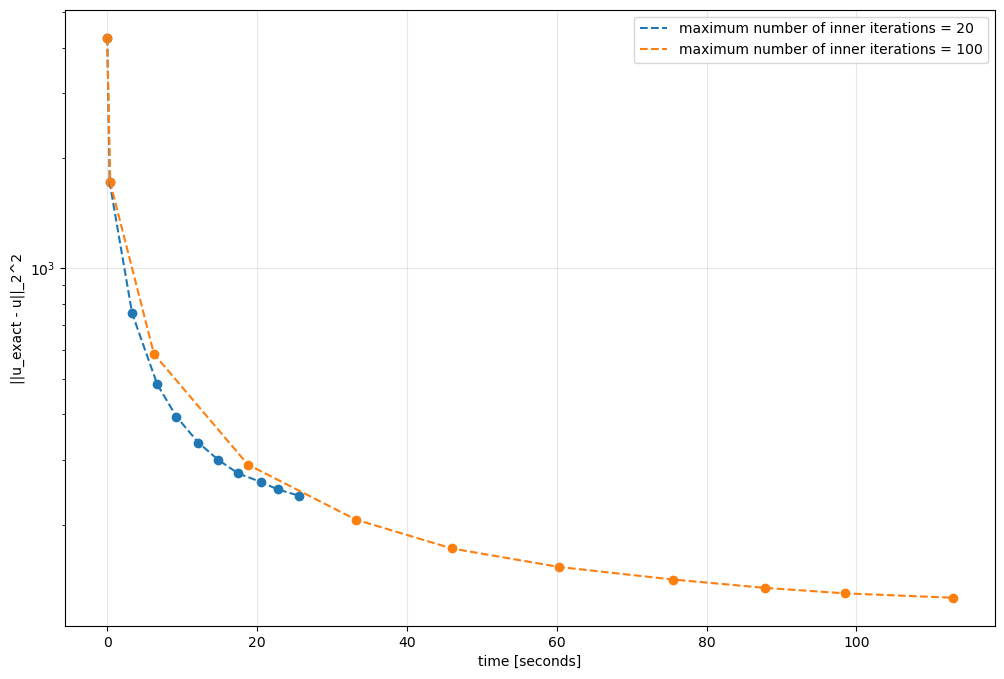

In [58]:

plt.figure(figsize=(12,8))
plt.semilogy(time_cg10, err_cg10, label="maximum number of inner iterations = 20", linestyle='--')
plt.scatter(time_cg10, err_cg10)
plt.semilogy(time_cg100, err_cg100, label="maximum number of inner iterations = 100", linestyle='--')
plt.scatter(time_cg100, err_cg100)
# plt.plot(time_fista, err_fista, label="fista")
# plt.scatter(time_fista, err_fista)
plt.ylabel('||u_exact - u||_2^2')
plt.xlabel('time [seconds]')
plt.grid(alpha=0.3)
plt.legend()